# 06 - Select Top N Classes

Filters the dataset to the TOP_K most frequent classes (`label`) and saves the result under a fixed output name for downstream use.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

INPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_anomaly_clean.csv'
TOP_N = 30

OUTPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_topn_classes.csv'
OUTPUT_LABELS_CSV = PROJECT_ROOT / 'merged_datasets' / 'topn_labels.csv'

print('INPUT_CSV:', INPUT_CSV)
print('OUTPUT_CSV:', OUTPUT_CSV)
print('OUTPUT_LABELS_CSV:', OUTPUT_LABELS_CSV)
print('TOP_N:', TOP_N)

INPUT_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_anomaly_clean.csv
OUTPUT_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_classes.csv
OUTPUT_LABELS_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\topn_labels.csv
TOP_N: 30


In [3]:
df = pd.read_csv(INPUT_CSV)

print('Shape:', df.shape)
print('Unique classes:', df['label'].nunique())

display(df.head())

Shape: (28689, 23)
Unique classes: 2054


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height,invalid_duration,invalid_fps,invalid_length_frames,duration_from_frames,consistency_error_sec,is_consistency_outlier,extreme_low_thr,extreme_high_thr,is_extreme_duration,is_anomaly,removal_reason
0,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_CBQXPn152YI...,3523,3609.0,87.0,3.440,25.00,msasl_172,True,640.0,360.0,False,False,False,3.480000,0.040000,False,0.467,8.125,False,False,NaN
1,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_R_ES8RZua1g...,675,734.0,60.0,1.967,30.00,msasl_40,True,568.0,320.0,False,False,False,2.000000,0.033000,False,0.467,8.125,False,False,NaN
2,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_VcRx3U-HpTE...,8111,8197.0,87.0,3.583,24.00,msasl_125,True,1280.0,720.0,False,False,False,3.625000,0.042000,False,0.467,8.125,False,False,NaN
3,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_LNEzl4vTVyE...,4840,4881.0,42.0,1.368,29.97,msasl_26,True,1280.0,720.0,False,False,False,1.401401,0.033401,False,0.467,8.125,False,False,NaN
4,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_LNEzl4vTVyE...,5514,5545.0,32.0,1.034,29.97,msasl_26,True,1280.0,720.0,False,False,False,1.067734,0.033734,False,0.467,8.125,False,False,NaN


In [4]:
label_counts = df['label'].value_counts()
topn_labels = label_counts.head(TOP_N).index.tolist()

topn_df = df[df['label'].isin(topn_labels)].copy()
topn_counts = topn_df['label'].value_counts()

print('Classes after filtering:', topn_df['label'].nunique())
print('Shape after filtering:', topn_df.shape)

display(topn_counts.to_frame('count').head(TOP_N))

Classes after filtering: 30
Shape after filtering: (1647, 23)


,count
label,
eat,67
bird,61
teacher,61
nice,61
need,60
mother,59
spring,59
orange,58
finish,57


In [5]:
topn_df.to_csv(OUTPUT_CSV, index=False)
pd.DataFrame({'label': topn_labels}).to_csv(OUTPUT_LABELS_CSV, index=False)

print('Saved:')
print('-', OUTPUT_CSV)
print('-', OUTPUT_LABELS_CSV)

Saved:
- C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_classes.csv
- C:\Users\kacpe\source\repos\szum\merged_datasets\topn_labels.csv


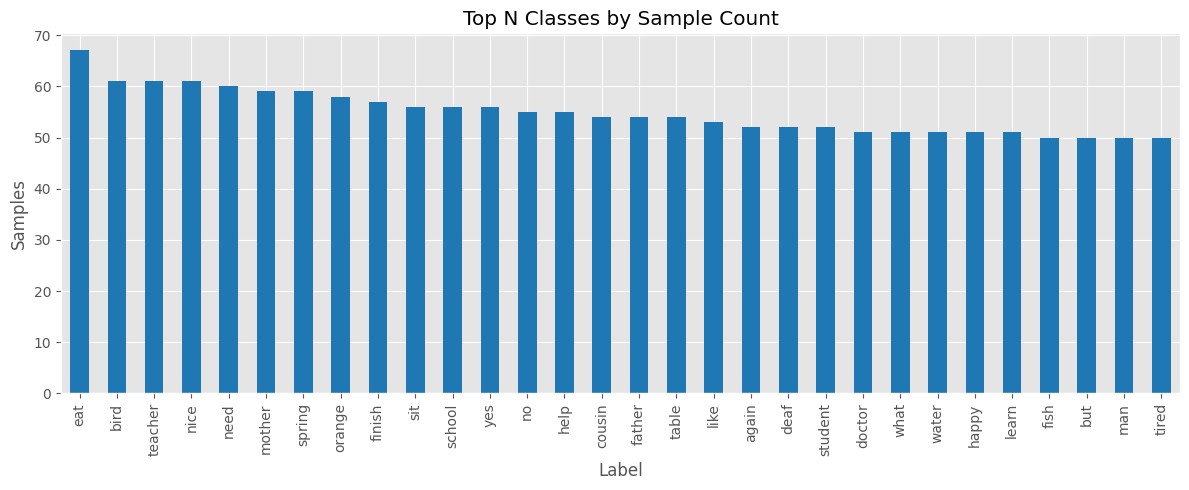

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
topn_counts.sort_values(ascending=False).plot(kind='bar', ax=ax, color='#1f77b4')
ax.set_title('Top N Classes by Sample Count')
ax.set_xlabel('Label')
ax.set_ylabel('Samples')
plt.tight_layout()
plt.show()